# Agrupamento de Municípios do RJ por K-Means

Agrupar os 92 municípios do Rio de Janeiro em perfis semelhantes de saneamento básico, usando o algoritmo K-Means

In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples

## 1. Carregamento dos dados

In [98]:
RENAME_COLS = {
    "Município": "nome_municipio",
    "Sigla UF": "sigla_uf",
    "População Total Residente": "populacao_total_residente",
    "População Rural Residente": "populacao_rural_residente",
    "População Urbana Residente": "populacao_urbana_residente",
    "População total atendida com abastecimento de água": "populacao_atendida_agua",
    "População urbana atendida com rede de abastecimento de água": "populacao_urbana_atendida_agua",
    "Atendimento da população urbana com rede de abastecimento de água": "indice_atendimento_urbano_agua",
    "Atendimento da população total com rede de abastecimento de água": "indice_atendimento_total_agua",
    "População total atendida com esgotamento sanitário": "populacao_atendida_esgoto",
    "População urbana atendida com rede de esgotamento sanitário": "populacao_urbana_atendida_esgoto",
    "Extensão de rede de distribuição de água": "extensao_rede_agua",
    "Extensão da rede pública de esgotamento sanitário": "extensao_rede_esgoto",
    "Quantidade de ligações ativas de água": "ligacoes_ativas_agua",
    "Quantidade de ligações ativas de esgoto": "ligacoes_ativas_esgoto",
    "Volume de água produzido": "volume_agua_produzido",
    "Volume de água tratada em ETAs": "volume_agua_tratada_eta",
    "Volume de água consumido": "volume_agua_consumido",
    "Volume de água tratada por simples desinfecção": "volume_agua_desinfeccao",
    "Volume de água tratada importado": "volume_agua_importado",
    "Volume de água tratada exportado": "volume_agua_exportado",
    "Volume de água fluoretada": "volume_agua_fluoretada",
    "Extensão de rede de distribuição de água.1": "extensao_rede_agua_2",
    "Volume total de esgoto coletado": "volume_esgoto_coletado",
    "Volume total de esgoto tratado ": "volume_esgoto_tratado",
    "Volume total de esgoto bruto exportado ": "volume_esgoto_exportado",
    "Volume total de esgoto bruto importado para tratamento ": "volume_esgoto_importado",
    "Extensão da rede pública de esgotamento sanitário.1": "extensao_rede_esgoto_2",
    "Atendimento da população urbana com rede coletora de esgoto": "indice_coleta_esgoto",
    "Esgoto tratado referido ao esgoto coletado": "indice_tratamento_esgoto",
    "Perda na Distribuição de Água": "indice_perda_distribuicao_agua",
    "Índice de Macromedição": "indice_macromedicao",
    "Índice de Hidrometração": "indice_hidrometracao",
    "Investimento Total (prestador + município + estado)": "investimento_total",
    "Investimento per Capita": "investimento_per_capita",
    "Quantidade de domicílios totais": "domicilios_totais",
    "Quantidade de domicílios urbanos": "domicilios_urbanos",
    "Quantidade de domicílios rurais": "domicilios_rurais",
    "Área do município": "area_municipio",
    "Cobertura da população total com coleta de resíduos sólidos domiciliares": "cobertura_residuos_solidos",
    "Cobertura da população urbana com coleta de resíduos sólidos domiciliares": "cobertura_residuos_urbana",
    "Cobertura da população rural com coleta de resíduos sólidos domiciliares": "cobertura_residuos_rural",
    "Cobertura da população urbana com coleta direta de resíduos sólidos": "cobertura_residuos_urbana_direta",
    "Cobertura da população total com coleta seletiva de resíduos sólidos": "cobertura_coleta_seletiva",
    "Cobertura da população urbana com coleta seletiva direta de resíduos sólidos": "cobertura_coleta_seletiva_urbana",
    "Incidência do transbordo de resíduos sólidos urbanos": "incidencia_transbordo_rsu",
    "Capacidade média utilizada dos veículos motorizados na coleta de RSU": "capacidade_veiculos_coleta",
    "Quantidade média de pontos de entrega voluntária (PEV) de recicláveis por mil habitantes": "pev_por_mil_hab",
    "Massa média per capita de resíduos sólidos urbanos coletados": "massa_rsu_per_capita",
    "Massa média per capita de resíduos sólidos domiciliares coletados": "massa_rsd_per_capita",
    "Massa média per capita de resíduos de limpeza urbana coletados": "massa_limpeza_urbana_per_capita",
    "Massa média per capita de resíduos domiciliares coletados na coleta seletiva": "massa_coleta_seletiva_per_capita",
    "Massa média per capita de resíduos domiciliares secos e orgânicos recuperados": "massa_recuperados_per_capita",
    "Desempenho da coleta seletiva": "desempenho_coleta_seletiva",
    "Disposição final inadequada de resíduos sólidos urbanos": "disposicao_final_inadequada_rsu",
    "Recuperação de recicláveis secos em relação à composição gravimétrica": "recuperacao_secos_gravimetria",
    "Recuperação de recicláveis orgânicos em relação à composição gravimétrica": "recuperacao_organicos_gravimetria",
    "Recuperação de recicláveis secos e orgânicos em relação ao total coletado": "recuperacao_total_coletado",
    "Recuperação de recicláveis secos em relação ao total coletado": "recuperacao_secos_total",
    "Recuperação de recicláveis orgânicos em relação ao total coletado": "recuperacao_organicos_total",
}

path = "../data/processed/snis_sinisa_merge_ibge_populacao.csv"
df = pd.read_csv(path, encoding="utf-8")
df.rename(columns=RENAME_COLS, inplace=True)

df["ano"] = df["ano"].astype(int)
df["id_municipio"] = df["id_municipio"].astype(str).str.strip()

ultimo_ano = df["ano"].max()
print(f"Último ano disponível: {ultimo_ano}")
print(f"Total de linhas: {len(df)}, Colunas: {len(df.columns)}")
df.head()


Último ano disponível: 2024
Total de linhas: 980, Colunas: 62


,ano,id_municipio,nome_municipio,sigla_uf,populacao_total_residente,populacao_rural_residente,populacao_urbana_residente,populacao_atendida_agua,populacao_urbana_atendida_agua,indice_atendimento_urbano_agua,...,massa_limpeza_urbana_per_capita,massa_coleta_seletiva_per_capita,massa_recuperados_per_capita,desempenho_coleta_seletiva,disposicao_final_inadequada_rsu,recuperacao_secos_gravimetria,recuperacao_organicos_gravimetria,recuperacao_total_coletado,recuperacao_secos_total,recuperacao_organicos_total
0,2024,3300100,Angra dos Reis,RJ,184940,6787,178153,116428.0,164070.0,93.72,...,1.11,0.0,0.00,0.0,0.0,NaN,NaN,0.00,0.00,0.0
1,2024,3300159,Aperibé,RJ,10882,1422,9460,5659.0,10480.0,100.00,...,0.26,0.0,0.00,0.0,0.0,NaN,NaN,0.00,0.00,0.0
2,2024,3300209,Araruama,RJ,120948,5963,114985,103143.0,132235.0,100.00,...,0.70,0.0,0.00,0.0,0.0,NaN,NaN,0.00,0.00,0.0
3,2024,3300225,Areal,RJ,11879,1560,10319,NaN,11251.0,100.00,...,0.81,27.6,27.59,4.1,0.0,NaN,NaN,2.77,2.77,0.0
4,2024,3300233,Armação dos Búzios,RJ,30439,0,30439,38198.0,41593.0,98.00,...,0.58,0.0,0.00,0.0,0.0,NaN,NaN,0.00,0.00,0.0


In [99]:
df = pd.read_csv(path, encoding="utf-8")
df.rename(columns=RENAME_COLS, inplace=True)

df["ano"] = df["ano"].astype(int)
df["id_municipio"] = df["id_municipio"].astype(str).str.strip()

ultimo_ano = df["ano"].max()
print(f"Último ano disponível: {ultimo_ano}")
print(f"Total de linhas: {len(df)}, Colunas: {len(df.columns)}")
df.head()

df_atual = df[df["ano"] == ultimo_ano].copy()

pop_urb = df_atual["populacao_urbana_residente"]
pop_tot = df_atual["populacao_total_residente"]
df_atual["pct_populacao_urbana"] = np.where(
    pop_tot.notna() & (pop_tot > 0),
    (pop_urb / pop_tot * 100).round(1),
    np.nan,
)

print(f"Municípios no ano {ultimo_ano}: {len(df_atual)}")
df_atual[["nome_municipio", "populacao_total_residente", "pct_populacao_urbana"]].head(10)

Último ano disponível: 2024
Total de linhas: 980, Colunas: 62
Municípios no ano 2024: 91


,nome_municipio,populacao_total_residente,pct_populacao_urbana
0,Angra dos Reis,184940,96.3
1,Aperibé,10882,86.9
2,Araruama,120948,95.1
3,Areal,11879,86.9
4,Armação dos Búzios,30439,100.0
5,Arraial do Cabo,28866,100.0
6,Barra do Piraí,96568,97.0
7,Barra Mansa,179697,99.1
8,Belford Roxo,479386,100.0
9,Bom Jardim,26126,60.3


## 2. Definição das variáveis 

6 variáveis:

| Variável | Fonte | Descrição |
|---|---|---|
| `indice_atendimento_total_agua` | SNIS | Cobertura de água (% da população) |
| `indice_coleta_esgoto` | SNIS | Cobertura de coleta de esgoto (%) |
| `cobertura_residuos_solidos` | SINISA | Cobertura de coleta de resíduos sólidos (%) |
| `disposicao_final_inadequada_rsu` | SINISA | Disposição final inadequada de RSU (%) |
| `pct_populacao_urbana` | IBGE/SNIS | Percentual de população urbana (%) |
| `indice_perda_distribuicao_agua` | SNIS | Perda na distribuição de água (%) |

In [100]:
FEATURES = [
    "indice_atendimento_total_agua",
    "indice_coleta_esgoto",
    "cobertura_residuos_solidos",
    "disposicao_final_inadequada_rsu",
    "pct_populacao_urbana",
    "indice_perda_distribuicao_agua",
]

LABELS = {
    "indice_atendimento_total_agua": "Água (%)",
    "indice_coleta_esgoto": "Esgoto (%)",
    "cobertura_residuos_solidos": "Resíduos (%)",
    "disposicao_final_inadequada_rsu": "Disp. Inadequada (%)",
    "pct_populacao_urbana": "Pop. Urbana (%)",
    "indice_perda_distribuicao_agua": "Perda Água (%)",
}

## 3. Tratamento de dados faltantes

- Municípios com até 2 variáveis faltantes: valores ausentes são preenchidos pela mediana da coluna
- Municípios com mais2 variáveis faltantes: são excluídos da análise

In [101]:
df_cl = df_atual[["id_municipio", "nome_municipio"] + FEATURES].copy()

print("Dados faltantes ANTES do tratamento:")
for c in FEATURES:
    n = df_cl[c].isna().sum()
    print(f"  {LABELS[c]:25s} → {n:3d} nulos ({n/len(df_cl)*100:.0f}%)")

n_missing = df_cl[FEATURES].isna().sum(axis=1)
print(f"\nDistribuição de nulos por município:")
print(n_missing.value_counts().sort_index().to_string())

Dados faltantes ANTES do tratamento:
  Água (%)                  →   4 nulos (4%)
  Esgoto (%)                →  25 nulos (27%)
  Resíduos (%)              →   3 nulos (3%)
  Disp. Inadequada (%)      →   3 nulos (3%)
  Pop. Urbana (%)           →   0 nulos (0%)
  Perda Água (%)            →   4 nulos (4%)

Distribuição de nulos por município:
0    58
1    29
2     2
3     2


In [102]:
excluidos = df_cl[n_missing > 2][["nome_municipio"]].copy()
excluidos["nulos"] = n_missing[n_missing > 2].values
if len(excluidos) > 0:
    print(f"{len(excluidos)} municípios EXCLUÍDOS (mais de 2 variáveis faltantes):")
    display(excluidos)
else:
    print("Nenhum município excluído.")

medianas = df_cl[FEATURES].median()
print(f"\nMedianas estaduais usadas para imputação:")
for c in FEATURES:
    print(f"  {LABELS[c]:25s} → {medianas[c]:.1f}")

df_cl.loc[n_missing <= 2, FEATURES] = df_cl.loc[n_missing <= 2, FEATURES].fillna(medianas)
df_cl = df_cl.dropna(subset=FEATURES).reset_index(drop=True)

print(f"\nMunicípios incluídos na clusterização: {len(df_cl)}")

2 municípios EXCLUÍDOS (mais de 2 variáveis faltantes):


,nome_municipio,nulos
13,Cambuci,3
25,Engenheiro Paulo de Frontin,3



Medianas estaduais usadas para imputação:
  Água (%)                  → 97.9
  Esgoto (%)                → 72.4
  Resíduos (%)              → 100.0
  Disp. Inadequada (%)      → 0.0
  Pop. Urbana (%)           → 88.1
  Perda Água (%)            → 36.6

Municípios incluídos na clusterização: 89


## 4. Análise exploratória das variáveis

distribuição de cada variável.

In [103]:
print("Estatísticas descritivas:")
df_cl[FEATURES].describe().round(1).rename(columns=LABELS)

Estatísticas descritivas:


,Água (%),Esgoto (%),Resíduos (%),Disp. Inadequada (%),Pop. Urbana (%),Perda Água (%)
count,89.0,89.0,89.0,89.0,89.0,89.0
mean,90.9,62.3,95.9,10.7,84.4,39.5
std,15.0,32.2,6.6,29.4,15.4,19.0
min,28.2,0.0,71.3,0.0,36.5,8.5
25%,89.2,32.0,94.1,0.0,75.5,25.4
50%,97.9,72.4,100.0,0.0,88.1,36.6
75%,100.0,86.7,100.0,0.0,97.0,46.7
max,100.0,100.0,100.0,100.0,100.0,99.1


## 5. Normalização (escala 0–1)

Aplicamos a **normalização mínimo-máximo** (MinMaxScaler) para que todas as variáveis fiquem entre 0 e 1.

Fórmula: $x_{norm} = \frac{x - x_{min}}{x_{max} - x_{min}}$

In [105]:
X = df_cl[FEATURES].values
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

df_scaled = pd.DataFrame(X_scaled, columns=[LABELS[f] for f in FEATURES])
print("Dados normalizados (primeiras 5 linhas):")
df_scaled.head()

Dados normalizados (primeiras 5 linhas):


,Água (%),Esgoto (%),Resíduos (%),Disp. Inadequada (%),Pop. Urbana (%),Perda Água (%)
0,0.888533,0.64190,1.0,0.0,0.941732,0.141171
1,1.000000,0.54000,1.0,0.0,0.793701,0.353921
2,1.000000,0.78000,1.0,0.0,0.922835,0.150877
3,1.000000,0.72365,1.0,0.0,0.793701,0.002978
4,0.972133,0.90000,1.0,0.0,1.000000,0.390758


In [106]:
print("Verificação da normalização (min e max devem ser 0 e 1):")
df_scaled.describe().loc[["min", "max"]].round(3)

Verificação da normalização (min e max devem ser 0 e 1):


,Água (%),Esgoto (%),Resíduos (%),Disp. Inadequada (%),Pop. Urbana (%),Perda Água (%)
min,0.0,0.0,0.0,0.0,0.0,0.0
max,1.0,1.0,1.0,1.0,1.0,1.0


## 6. Escolha do número de grupos (k)

Testamos k de 2 a 6 e avaliamos com dois métodos:

- **Método do Cotovelo (inércia):** A inércia é a soma das distâncias de cada ponto ao centro do seu grupo. Procuramos o ponto onde a curva "dobra".

- **Pontuação de Silhueta:** Mede coesão interna e separação entre grupos. Varia de -1 a +1. O k com maior silhueta produz os grupos mais bem definidos.

In [107]:
K_range = range(2, 7)
inertias = []
sil_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled, labels)
    sil_scores.append(sil)
    print(f"k={k}: Inércia={km.inertia_:.2f}, Silhueta={sil:.4f}")

best_k = list(K_range)[np.argmax(sil_scores)]
if best_k < 3:
    print(f"\nSilhueta máxima em k={best_k}, mas forçando k=4 conforme regras.md")
    best_k = 4
else:
    print(f"\n→ Melhor k pela silhueta: {best_k} (silhueta = {max(sil_scores):.4f})")

k=2: Inércia=25.98, Silhueta=0.3054


k=3: Inércia=19.19, Silhueta=0.3570
k=4: Inércia=15.01, Silhueta=0.3413
k=5: Inércia=12.76, Silhueta=0.3546
k=6: Inércia=11.27, Silhueta=0.3177

→ Melhor k pela silhueta: 3 (silhueta = 0.3570)


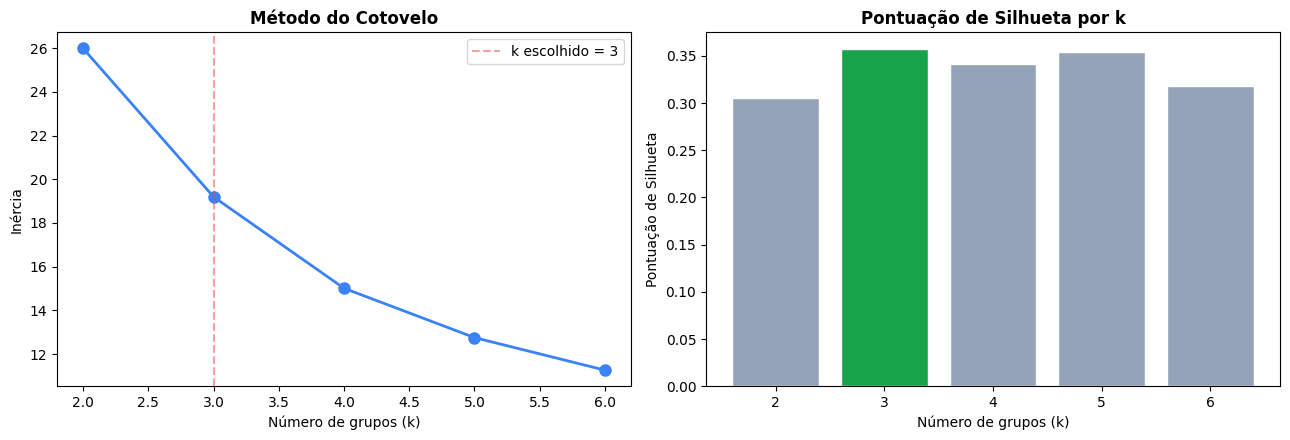

In [108]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

ax1.plot(list(K_range), inertias, "o-", color="#3b82f6", lw=2, markersize=8)
ax1.set_xlabel("Número de grupos (k)")
ax1.set_ylabel("Inércia")
ax1.set_title("Método do Cotovelo", fontweight="bold")
ax1.axvline(best_k, color="#ef4444", ls="--", alpha=0.5, label=f"k escolhido = {best_k}")
ax1.legend()

colors = ["#16a34a" if k == best_k else "#94a3b8" for k in K_range]
ax2.bar(list(K_range), sil_scores, color=colors, edgecolor="white")
ax2.set_xlabel("Número de grupos (k)")
ax2.set_ylabel("Pontuação de Silhueta")
ax2.set_title("Pontuação de Silhueta por k", fontweight="bold")

plt.tight_layout()
plt.show()

## 7. Execução final do K-Means

Rodamos o algoritmo com o k selecionado. O parâmetro `n_init=10` executa o algoritmo 10 vezes com inicializações diferentes e escolhe o resultado com menor inércia. O `random_state=42` garante reprodutibilidade.

In [109]:
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_cl["cluster"] = km_final.fit_predict(X_scaled)

print(f"Distribuição dos municípios por grupo:")
print(df_cl["cluster"].value_counts().sort_index().to_string())
print(f"\nInércia final: {km_final.inertia_:.2f}")
print(f"Silhueta final: {silhouette_score(X_scaled, df_cl['cluster']):.4f}")

Distribuição dos municípios por grupo:
cluster
0     9
1    60
2    20

Inércia final: 19.19
Silhueta final: 0.3570


## 8. Análise de Silhueta por município

A silhueta individual mostra quão bem cada município se encaixa no seu grupo. Valores próximos de +1 indicam boa classificação; valores negativos indicam que o município talvez pertença a outro grupo.

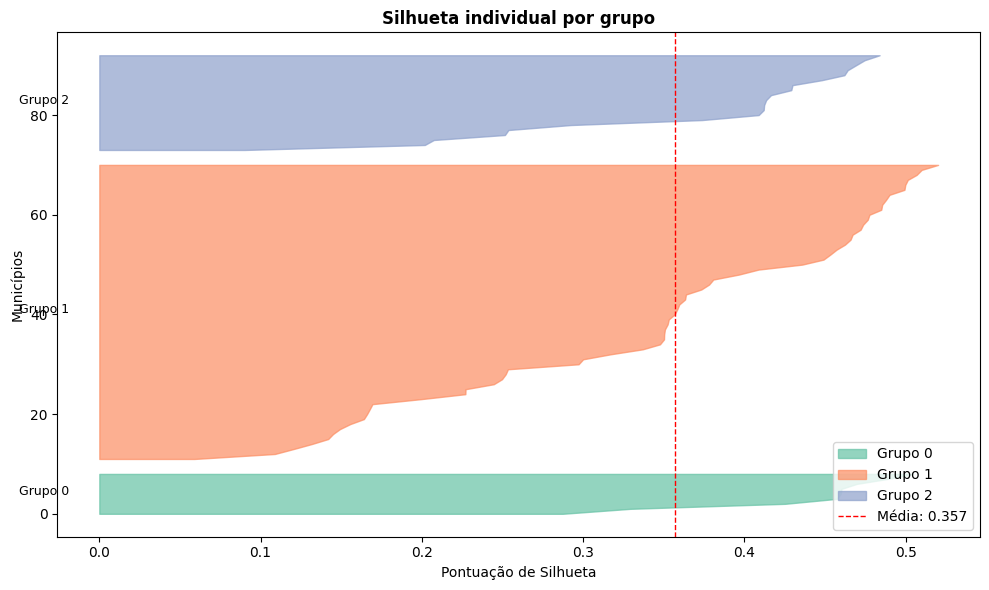


Todos os municípios têm silhueta positiva.


In [110]:
sil_vals = silhouette_samples(X_scaled, df_cl["cluster"])
df_cl["silhueta"] = sil_vals

fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 0
cores = sns.color_palette("Set2", best_k)

for i in range(best_k):
    vals = np.sort(sil_vals[df_cl["cluster"] == i])
    size = len(vals)
    y_upper = y_lower + size
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals, alpha=0.7, color=cores[i], label=f"Grupo {i}")
    ax.text(-0.05, y_lower + size / 2, f"Grupo {i}", fontsize=9, va="center")
    y_lower = y_upper + 2

ax.axvline(sil_vals.mean(), color="red", ls="--", lw=1, label=f"Média: {sil_vals.mean():.3f}")
ax.set_xlabel("Pontuação de Silhueta")
ax.set_ylabel("Municípios")
ax.set_title("Silhueta individual por grupo", fontweight="bold")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

mal_classificados = df_cl[df_cl["silhueta"] < 0][["nome_municipio", "cluster", "silhueta"]]
if len(mal_classificados) > 0:
    print(f"\n{len(mal_classificados)} municípios com silhueta negativa (possível reclassificação):")
    display(mal_classificados.sort_values("silhueta"))
else:
    print("\nTodos os municípios têm silhueta positiva.")

## 9. Perfil médio de cada grupo

Calculamos a média de cada variável por grupo para entender o que caracteriza cada agrupamento.

In [111]:
profiles = df_cl.groupby("cluster")[FEATURES].agg(["mean", "std"]).round(1)
profiles_mean = df_cl.groupby("cluster")[FEATURES].mean().round(1)

def nome_cluster(row):
    """
    Classificação baseada na terminologia do PLANSAB (Lei 11.445/2007
    atualizada pela Lei 14.026/2020 - Marco Legal do Saneamento).

    Limiares:
    - Água >= 90%: próximo da universalização (meta: 99% até 2033)
    - Esgoto >= 75%: atendimento adequado (meta: 90% até 2033)
    - RSU >= 80%: atendimento adequado (PLANSAB)
    - pct_urb: variável de contexto, não critério classificatório
    """
    agua = row.get("indice_atendimento_total_agua", 0)
    esgoto = row.get("indice_coleta_esgoto", 0)
    residuos = row.get("cobertura_residuos_solidos", 0)
    pct_urb = row.get("pct_populacao_urbana", 50)
    rural = pct_urb < 50

    if agua >= 90 and esgoto >= 75 and residuos >= 80:
        return "Atendimento adequado consolidado"

    if agua >= 70 and esgoto < 50:
        if esgoto < 30:
            return "Déficit severo de esgotamento sanitário"
        return "Déficit de esgotamento sanitário"

    if agua < 60:
        if esgoto < 30:
            return "Déficit crítico - água e esgoto"
        return "Déficit de abastecimento de água"

    n_deficit = sum([agua < 70, esgoto < 50, residuos < 50])
    if n_deficit >= 2:
        if rural:
            return "Déficit estrutural - município rural vulnerável"
        return "Déficit estrutural de saneamento"

    return "Atendimento precário"

nomes = {i: nome_cluster(profiles_mean.loc[i]) for i in profiles_mean.index}
df_cl["grupo"] = df_cl["cluster"].map(nomes)

display_profiles = profiles_mean.copy()
display_profiles.index = [nomes[i] for i in display_profiles.index]
display_profiles = display_profiles.rename(columns=LABELS)

print("Perfil médio de cada grupo (terminologia PLANSAB):")
display(display_profiles)


Perfil médio de cada grupo (terminologia PLANSAB):


,Água (%),Esgoto (%),Resíduos (%),Disp. Inadequada (%),Pop. Urbana (%),Perda Água (%)
Atendimento precário,88.9,52.9,95.7,95.8,85.9,31.5
Atendimento adequado consolidado,93.1,80.8,95.6,1.5,83.9,38.5
Déficit severo de esgotamento sanitário,85.3,11.2,96.8,0.0,85.5,46.2


## 10. Análise de Componentes Principais

A ACP reduz as 6 variáveis a 2 eixos principais, preservando a maior variação possível dos dados. Isso permite visualizar os agrupamentos em um gráfico de dispersão.

In [112]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)
df_cl["pca1"] = coords[:, 0]
df_cl["pca2"] = coords[:, 1]

print(f"Variância explicada pelo Componente 1: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"Variância explicada pelo Componente 2: {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"Total explicado (2 componentes): {sum(pca.explained_variance_ratio_)*100:.1f}%")

Variância explicada pelo Componente 1: 29.1%
Variância explicada pelo Componente 2: 22.5%
Total explicado (2 componentes): 51.7%


In [113]:
print("Contribuição de cada variável original nos componentes:")
loadings = pd.DataFrame(
    pca.components_.T,
    index=[LABELS[f] for f in FEATURES],
    columns=["Componente 1", "Componente 2"],
).round(3)
display(loadings)

Contribuição de cada variável original nos componentes:


,Componente 1,Componente 2
Água (%),0.241,0.071
Esgoto (%),0.917,0.182
Resíduos (%),-0.077,-0.184
Disp. Inadequada (%),-0.263,0.922
Pop. Urbana (%),-0.073,-0.149
Perda Água (%),-0.142,-0.236


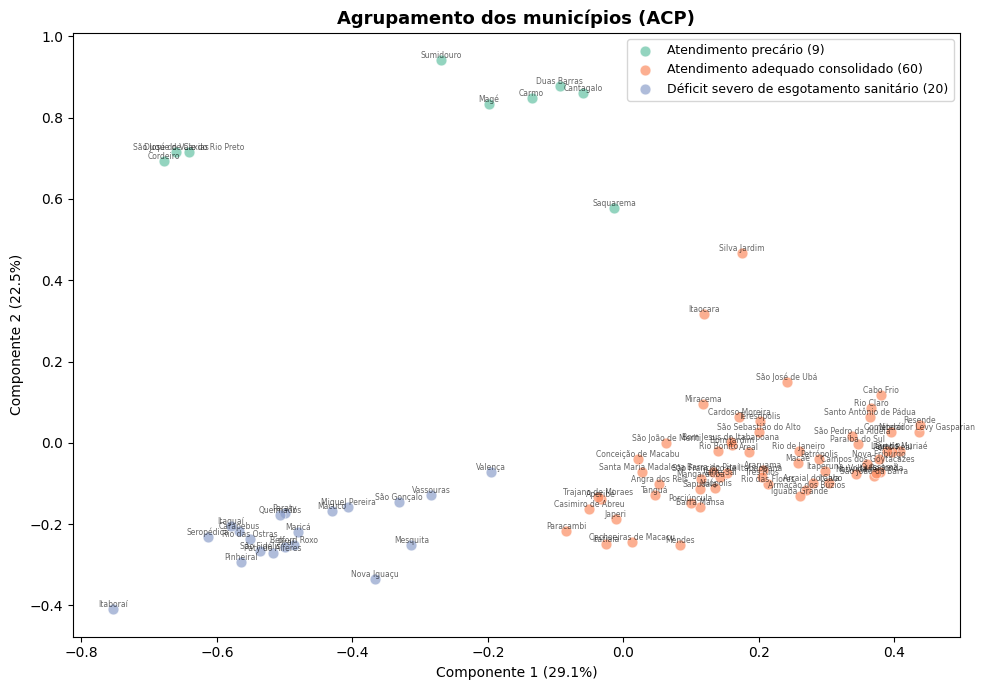

In [114]:
fig, ax = plt.subplots(figsize=(10, 7))
cores = sns.color_palette("Set2", best_k)

for i in range(best_k):
    mask = df_cl["cluster"] == i
    ax.scatter(df_cl.loc[mask, "pca1"], df_cl.loc[mask, "pca2"],
               c=[cores[i]], s=60, alpha=0.7, edgecolors="white", lw=0.5,
               label=f"{nomes[i]} ({mask.sum()})")

for _, row in df_cl.iterrows():
    ax.annotate(row["nome_municipio"], (row["pca1"], row["pca2"]),
                fontsize=5.5, alpha=0.6, ha="center", va="bottom")

ax.set_xlabel(f"Componente 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"Componente 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("Agrupamento dos municípios (ACP)", fontsize=13, fontweight="bold")
ax.legend(loc="best", fontsize=9)
plt.tight_layout()
plt.show()

## 11. Centróides

In [115]:
centroids_scaled = km_final.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)

df_centroids = pd.DataFrame(centroids_original, columns=[LABELS[f] for f in FEATURES])
df_centroids.index = [nomes[i] for i in range(best_k)]
print("Centróides em escala original:")
display(df_centroids.round(1))

Centróides em escala original:


,Água (%),Esgoto (%),Resíduos (%),Disp. Inadequada (%),Pop. Urbana (%),Perda Água (%)
Atendimento precário,88.9,52.9,95.7,95.8,85.9,31.5
Atendimento adequado consolidado,93.1,80.8,95.6,1.5,83.9,38.5
Déficit severo de esgotamento sanitário,85.3,11.2,96.8,0.0,85.5,46.2


## 12. Lista de municípios por grupo

In [116]:
for i in range(best_k):
    muns = sorted(df_cl[df_cl["cluster"] == i]["nome_municipio"].tolist())
    print(f"\n{'='*60}")
    print(f"GRUPO {i}: {nomes[i]} ({len(muns)} municípios)")
    print(f"{'='*60}")
    for m in muns:
        print(f"  • {m}")


GRUPO 0: Atendimento precário (9 municípios)
  • Cantagalo
  • Carmo
  • Cordeiro
  • Duas Barras
  • Duque de Caxias
  • Magé
  • Saquarema
  • Sumidouro
  • São José do Vale do Rio Preto

GRUPO 1: Atendimento adequado consolidado (60 municípios)
  • Angra dos Reis
  • Aperibé
  • Araruama
  • Areal
  • Armação dos Búzios
  • Arraial do Cabo
  • Barra Mansa
  • Barra do Piraí
  • Bom Jardim
  • Bom Jesus do Itabapoana
  • Cabo Frio
  • Cachoeiras de Macacu
  • Campos dos Goytacazes
  • Cardoso Moreira
  • Casimiro de Abreu
  • Comendador Levy Gasparian
  • Conceição de Macabu
  • Iguaba Grande
  • Italva
  • Itaocara
  • Itaperuna
  • Itatiaia
  • Japeri
  • Laje do Muriaé
  • Macaé
  • Mangaratiba
  • Mendes
  • Miracema
  • Natividade
  • Nilópolis
  • Niterói
  • Nova Friburgo
  • Paracambi
  • Paraíba do Sul
  • Petrópolis
  • Porciúncula
  • Porto Real
  • Quatis
  • Quissamã
  • Resende
  • Rio Bonito
  • Rio Claro
  • Rio das Flores
  • Rio de Janeiro
  • Santa Maria Madalena


## 13. Exportação dos resultados

In [117]:
df_export = df_cl[["id_municipio", "nome_municipio", "cluster", "grupo", "silhueta"] + FEATURES].copy()
df_export = df_export.sort_values(["cluster", "nome_municipio"]).reset_index(drop=True)

output_path = "../data/processed/clusterizacao_municipios_rj.csv"
df_export.to_csv(output_path, index=False, encoding="utf-8")
print(f"Resultados exportados para: {output_path}")
print(f"Total de municípios classificados: {len(df_export)}")
df_export.head(10)

Resultados exportados para: ../data/processed/clusterizacao_municipios_rj.csv
Total de municípios classificados: 89


,id_municipio,nome_municipio,cluster,grupo,silhueta,indice_atendimento_total_agua,indice_coleta_esgoto,cobertura_residuos_solidos,disposicao_final_inadequada_rsu,pct_populacao_urbana,indice_perda_distribuicao_agua
0,3301108,Cantagalo,0,Atendimento precário,0.460187,100.00,72.365,91.97,93.31,70.7,33.96
1,3301207,Carmo,0,Atendimento precário,0.504662,93.80,72.365,93.09,100.00,80.7,48.63
2,3301504,Cordeiro,0,Atendimento precário,0.425148,100.00,13.000,100.00,100.00,99.7,34.92
3,3301603,Duas Barras,0,Atendimento precário,0.488702,100.00,72.365,100.00,100.00,71.9,29.97
4,3301702,Duque de Caxias,0,Atendimento precário,0.459682,81.66,20.000,99.76,100.00,96.6,27.77
5,3302502,Magé,0,Atendimento precário,0.469634,70.09,72.365,100.00,100.00,88.1,20.85
6,3305505,Saquarema,0,Atendimento precário,0.287293,97.88,74.520,96.52,69.30,82.2,36.63
7,3305703,Sumidouro,0,Atendimento precário,0.329351,56.68,63.150,80.00,100.00,89.3,16.49
8,3305158,São José do Vale do Rio Preto,0,Atendimento precário,0.457404,100.00,16.040,100.00,100.00,93.5,33.86
9,3300100,Angra dos Reis,1,Atendimento adequado consolidado,0.297151,92.00,64.190,100.00,0.00,96.3,21.27
